# Gravitational Velocity Selection

Atoms at 1 µK free-fall for τ, accumulating Doppler shift from gravity. A 400 µs π pulse
with detuning ε·δ (where δ = −gτ/λ is the resonant detuning for the fallen cloud centre)
selects a velocity slice; clearout removes ground-state atoms. Scan τ = 0 → 5 ms for
ε ∈ {0.99, 0.999, 1.0}.

In [17]:
import sys
sys.path.insert(0, '..')

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from tqdm import tqdm

import lmt_sim.version_info as vs
from lmt_sim.lmt_sequence import Pulse, Freefall, calculate_excited_fraction_for_pulse_sequence
from lmt_sim.lmt_simulation import K_WAVEVECTOR, MASS_ATOM

%matplotlib inline

In [19]:
g = 9.81          # m/s²
T = 1e-6          # 1 µK cloud temperature
T_SELECT = 400e-6 # π pulse duration → velocity selection bandwidth ~1/(2·T_SELECT) / (K/2π)
RABI_FREQ_SELECT = 1 / (2 * T_SELECT)  # gives π pulse area

N_ATOMS = 500
EPSILONS = [0.95, 0.99, 0.999, 1.0]
TAU_VALUES = np.linspace(0, 5e-3, 51)
BEAM_WAIST = 10e-6  # m

sigma_v = np.sqrt(constants.k * T / MASS_ATOM)

In [20]:
rng = np.random.default_rng(42)
v_thermal = rng.normal(0, sigma_v, (N_ATOMS, 3))
print(f"σ_v = {sigma_v*1e3:.2f} mm/s  (1D Maxwell-Boltzmann at {T*1e6:.0f} µK)")
print(f"velocity selection bandwidth ≈ {RABI_FREQ_SELECT * (2*np.pi/K_WAVEVECTOR)*1e3:.3f} mm/s")

σ_v = 9.78 mm/s  (1D Maxwell-Boltzmann at 1 µK)
velocity selection bandwidth ≈ 0.873 mm/s


In [21]:
v_thermal.shape

(500, 3)

In [22]:
from typing import cast

results = {}

for epsilon in EPSILONS:
    surviving = np.empty(len(TAU_VALUES))

    for i, tau in enumerate(tqdm(TAU_VALUES, desc=f"ε={epsilon}")):
        # Resonant detuning for cloud centre after falling at -g*tau in z (k=+1 laser, z up)
        delta = -g * tau * K_WAVEVECTOR / (2 * np.pi)

        sequence = [
            Freefall(duration=tau, label="freefall"),
            Pulse(
                k=+1,
                detuning_hz=epsilon * delta,
                phi=0.0,
                label="velocity_select",
                rabi_frequency=RABI_FREQ_SELECT,
                duration=T_SELECT,
                beam_waist=BEAM_WAIST,
            ),
        ]

        # Atom velocities at the moment of the π pulse (thermal + gravitational drift)
        v_pulse = v_thermal + g * tau * np.array([0, 0, -1])

        # Excited fraction = expected surviving fraction after clearout (deterministic)
        surviving[i] = np.mean(
            [
                cast(
                    float,
                    calculate_excited_fraction_for_pulse_sequence(
                        sequence, velocity=v, position=(0.0, 0.0, 0.0)
                    ),
                )
                for v in v_pulse
            ]
        )

    results[epsilon] = surviving

ε=1.0: 100%|██████████| 51/51 [00:10<00:00,  4.66it/s]


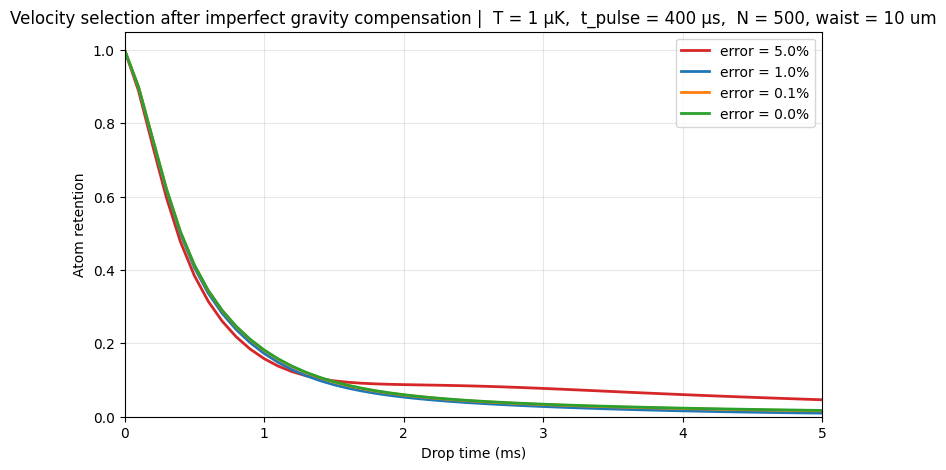

In [23]:
ref = results[1.0][0]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tab:red", "tab:blue", "tab:orange", "tab:green"]

for (eps, curve), color in zip(results.items(), colors):
    ax.plot(TAU_VALUES * 1e3, curve / ref, lw=2, color=color, label=f"error = {100 * (1 - eps):.1f}%")

ax.set_xlabel("Drop time (ms)")
ax.set_ylabel("Atom retention")
ax.set_title(
    f"Velocity selection after imperfect gravity compensation |  "
    f"T = {T*1e6:.0f} µK,  t_pulse = {T_SELECT*1e6:.0f} µs,  N = {N_ATOMS}, waist = {BEAM_WAIST*1e6:.0f} um"
)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 5)
ax.set_ylim(bottom=0)
vs.tag_plot(small=True)
